# TP Seaborn — Données sportives (FIFA/FC players)

## 0. Chargement des données et des librairies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

df = pd.read_csv("all_players_clean.csv")
df.shape

(17737, 55)

**Interprétation :** le dataset contient **17 737 joueurs** décrits par **55 colonnes** (statistiques de jeu, informations physiques, club, nation, ligue...). C'est un jeu de données riche qui mélange variables numériques (notes de 0 à 99) et variables catégorielles (texte).

In [2]:
df.head()

,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint.Speed,...,Nation,League,Team,url,GK.Diving,GK.Handling,GK.Kicking,GK.Positioning,GK.Reflexes,gender
0,Kylian Mbappé,91,97,90,80,92,36,78,97,97,...,France,LALIGA EA SPORTS,Real Madrid,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
1,Rodri,91,66,80,86,84,87,85,65,66,...,Spain,Premier League,Manchester City,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
2,Erling Haaland,91,88,92,70,81,45,88,80,94,...,Norway,Premier League,Manchester City,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
3,Jude Bellingham,90,80,87,83,88,78,83,81,80,...,England,LALIGA EA SPORTS,Real Madrid,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M
4,Vini Jr.,90,95,84,81,91,29,69,95,95,...,Brazil,LALIGA EA SPORTS,Real Madrid,https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN,M


**Interprétation :** on voit tout de suite la structure d'une ligne : un joueur (ex. Kylian Mbappé) avec sa note globale **OVR**, ses 6 statistiques FIFA (PAC, SHO, PAS, DRI, DEF, PHY), puis des détails plus fins (Acceleration, Sprint.Speed, ...) et des informations administratives (Team, League, Nation).

## 1. Compréhension du dataset

### 1.1 Colonnes quantitatives et qualitatives

In [3]:
quant_cols = df.select_dtypes(include="number").columns.tolist()
qual_cols = df.select_dtypes(exclude="number").columns.tolist()

print(f"{len(quant_cols)} colonnes quantitatives :")
print(quant_cols)
print()
print(f"{len(qual_cols)} colonnes qualitatives :")
print(qual_cols)

46 colonnes quantitatives :
['OVR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration', 'Sprint.Speed', 'Positioning', 'Finishing', 'Shot.Power', 'Long.Shots', 'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free.Kick.Accuracy', 'Short.Passing', 'Long.Passing', 'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions', 'Ball.Control', 'Composure', 'Interceptions', 'Heading.Accuracy', 'Def.Awareness', 'Standing.Tackle', 'Sliding.Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression', 'Weak.foot', 'Skill.moves', 'Height', 'Weight', 'Age', 'GK.Diving', 'GK.Handling', 'GK.Kicking', 'GK.Positioning', 'GK.Reflexes']

9 colonnes qualitatives :
['Name', 'Position', 'Preferred.foot', 'Alternative.positions', 'Nation', 'League', 'Team', 'url', 'gender']


**Interprétation :** on a **46 colonnes quantitatives** (toutes les notes de jeu : OVR, PAC, SHO, PAS, DRI, DEF, PHY, les sous-statistiques comme Acceleration ou Ball.Control, ainsi que Age, Height, Weight) et **9 colonnes qualitatives** (Name, Position, Preferred.foot, Alternative.positions, Nation, League, Team, url, gender). Cette distinction va guider tout le reste du TP : les univariées quantitatives utiliseront histplot/kdeplot, les qualitatives countplot.

### 1.2 Joueur avec la meilleure note OVR

In [4]:
best_player = df.loc[df["OVR"].idxmax()]
best_player[["Name", "OVR", "Team", "League", "Nation", "Position"]]

Name           Kylian Mbappé
OVR                       91
Team             Real Madrid
League      LALIGA EA SPORTS
Nation                France
Position                  ST
Name: 0, dtype: object

**Interprétation :** le joueur avec la meilleure note **OVR** est **Kylian Mbappé (91)**, évoluant au Real Madrid en LaLiga. Ce résultat est cohérent avec la réalité du jeu FIFA/FC où les attaquants stars occupent le haut du classement OVR.

### 1.3 Les 5 ligues les plus représentées

In [5]:
top5_leagues = df["League"].value_counts().head(5)
top5_leagues

League
Sudamericana        826
MLS                 762
EFL Championship    683
EFL League One      615
Premier League      597
Name: count, dtype: int64

/tmp/ipykernel_136/2339141925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5_leagues.values, y=top5_leagues.index, palette="viridis")


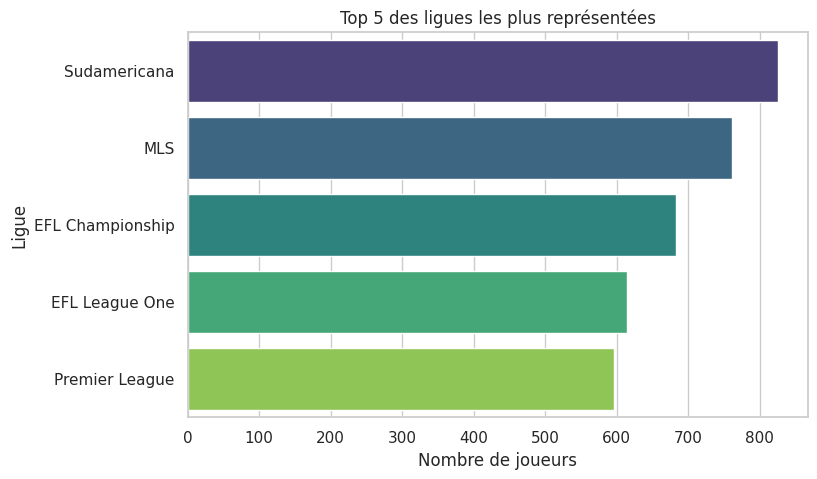

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(x=top5_leagues.values, y=top5_leagues.index, palette="viridis")
plt.xlabel("Nombre de joueurs")
plt.ylabel("Ligue")
plt.title("Top 5 des ligues les plus représentées")
plt.show()

**Interprétation :** les 5 ligues les plus représentées sont la **Sudamericana**, la **MLS**, l'**EFL Championship**, l'**EFL League One** et la **Premier League**. On remarque que les grandes ligues sud-américaines et les divisions inférieures anglaises comptent énormément de joueurs, probablement parce que le dataset couvre beaucoup de clubs par pays, pas seulement l'élite.

## 2. Visualisations univariées

### A. Variables quantitatives

#### 2.1 Distribution de la note générale OVR

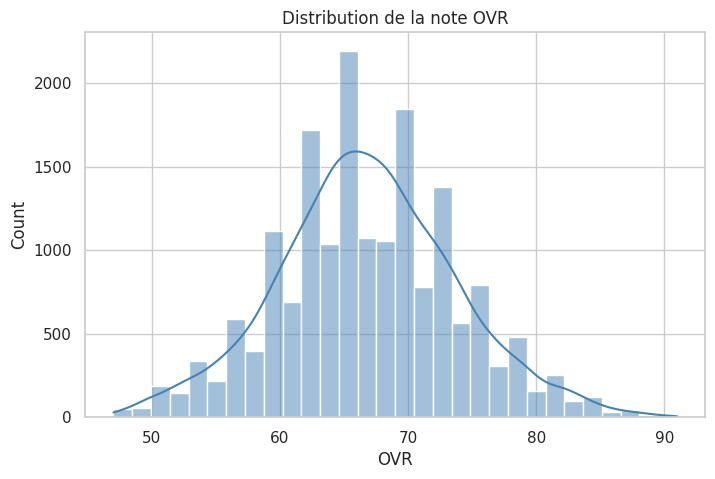

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["OVR"], bins=30, kde=True, color="steelblue")
plt.title("Distribution de la note OVR")
plt.xlabel("OVR")
plt.show()

**Interprétation :** la distribution de l'**OVR** est globalement en forme de cloche, centrée autour de **67** (moyenne ≈ 66,8, médiane 67), avec un écart-type d'environ 7. La grande majorité des joueurs se situe entre 60 et 72 ; les notes extrêmes (au-delà de 85) sont très rares, ce qui est logique puisque seule une poignée de superstars atteint ce niveau.

#### 2.2 Comparaison PAC vs PHY (deux histogrammes côte à côte)

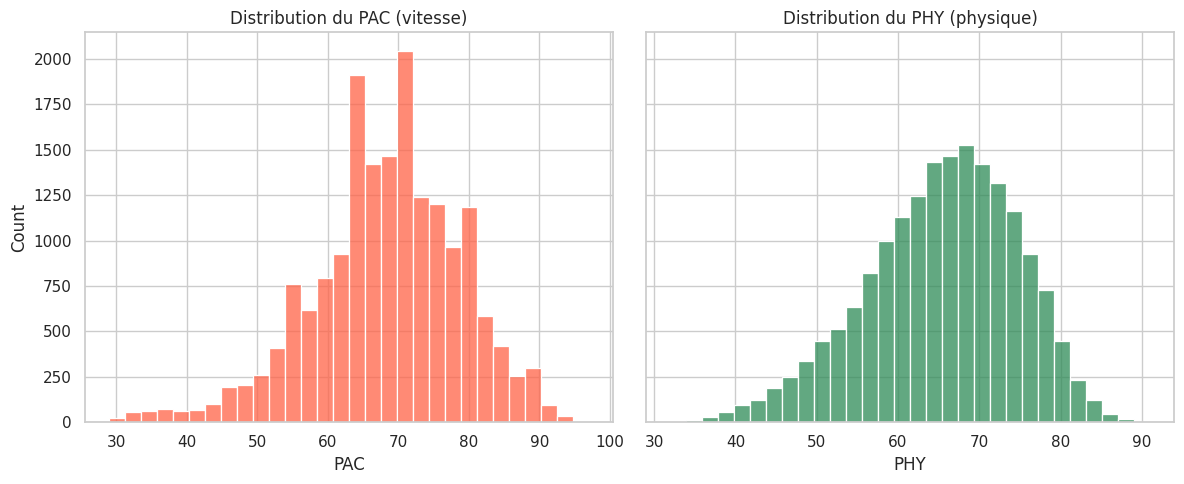

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
sns.histplot(df["PAC"], bins=30, color="tomato", ax=axes[0])
axes[0].set_title("Distribution du PAC (vitesse)")
sns.histplot(df["PHY"], bins=30, color="seagreen", ax=axes[1])
axes[1].set_title("Distribution du PHY (physique)")
plt.tight_layout()
plt.show()

**Interprétation :** le **PAC** (vitesse) présente une distribution plus étalée et légèrement décalée vers la gauche, avec un pic net autour de 60-70 — beaucoup de joueurs défensifs ou de gardiens ont un PAC assez faible. Le **PHY** (physique) est plus resserré et centré un peu plus haut, ce qui traduit le fait que la force physique est une qualité plus uniformément répartie entre les postes que la vitesse pure.

#### 2.3 Densité (kdeplot) du DRI (dribble)

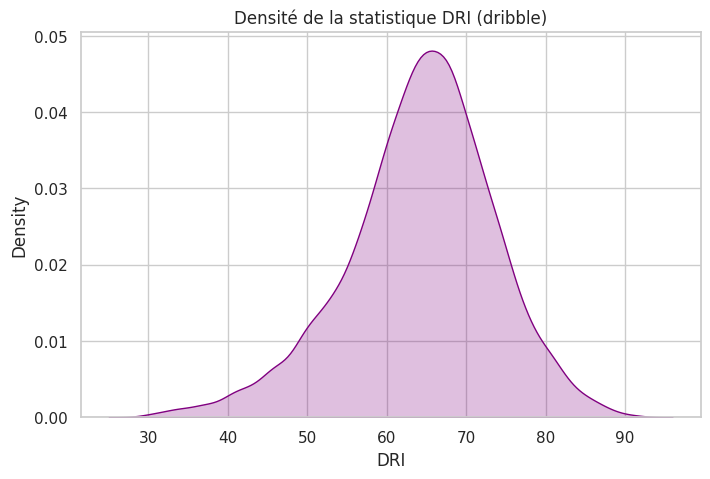

In [9]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["DRI"], fill=True, color="purple")
plt.title("Densité de la statistique DRI (dribble)")
plt.xlabel("DRI")
plt.show()

**Interprétation :** la densité du **DRI** montre une distribution asymétrique avec une masse importante entre 55 et 70, et une traîne plus longue vers les valeurs basses. Cela s'explique par les gardiens et défenseurs purs qui tirent la distribution vers le bas, alors que les profils offensifs et techniques (ailiers, milieux) forment le cœur de la distribution à des valeurs plus élevées.

### B. Variables qualitatives

#### 2.4 Championnats les plus représentés

/tmp/ipykernel_136/968009904.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="League", order=order, palette="mako")


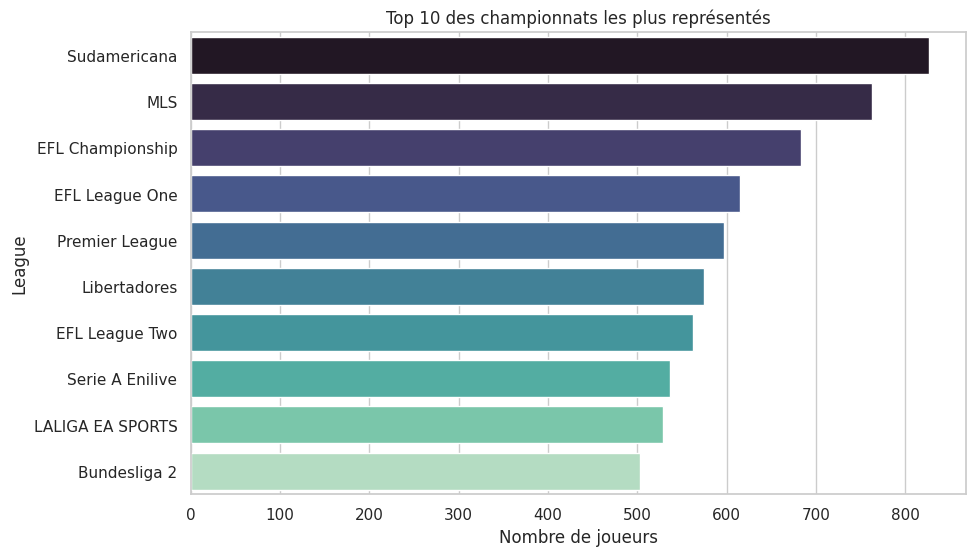

In [10]:
plt.figure(figsize=(10,6))
order = df["League"].value_counts().head(10).index
sns.countplot(data=df, y="League", order=order, palette="mako")
plt.title("Top 10 des championnats les plus représentés")
plt.xlabel("Nombre de joueurs")
plt.show()

**Interprétation :** on confirme le classement obtenu précédemment : la **Sudamericana** et la **MLS** arrivent en tête, suivies par plusieurs divisions anglaises (EFL Championship, League One, League Two) et la Premier League. Le dataset n'est donc pas centré uniquement sur les 5 grands championnats européens, il couvre un spectre beaucoup plus large de compétitions.

#### 2.5 Pays le plus présent dans le dataset

In [11]:
top_nations = df["Nation"].value_counts().head(10)
top_nations

Nation
England           1590
Germany           1324
Spain             1151
France             878
Argentina          865
United States      673
Italy              533
Holland            439
Korea Republic     412
Sweden             403
Name: count, dtype: int64

/tmp/ipykernel_136/976328739.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Nation", order=top_nations.index, palette="crest")


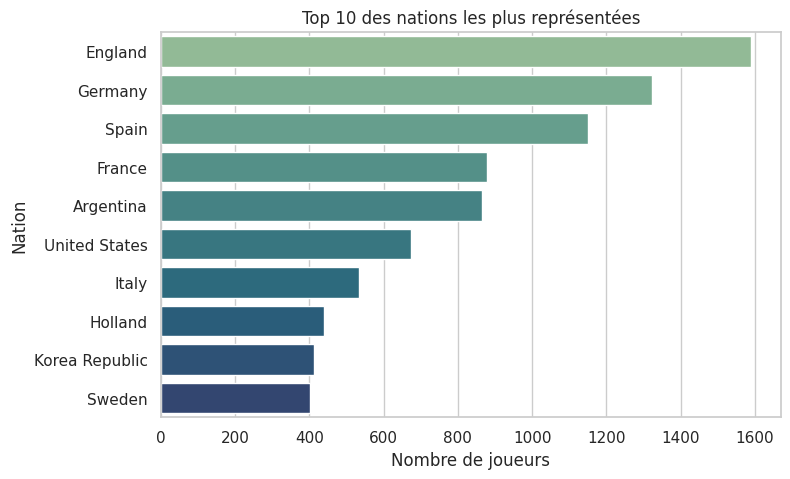

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Nation", order=top_nations.index, palette="crest")
plt.title("Top 10 des nations les plus représentées")
plt.xlabel("Nombre de joueurs")
plt.show()

**Interprétation :** l'**Angleterre** est la nation la plus représentée (environ 1 590 joueurs), devant l'**Allemagne**, l'**Espagne**, la **France** et l'**Argentine**. Ce résultat reflète à la fois le poids démographique du football dans ces pays et le grand nombre de divisions anglaises incluses dans le dataset.

## 3. Visualisations bivariées

#### 3.6 Relation entre PAC (vitesse) et OVR

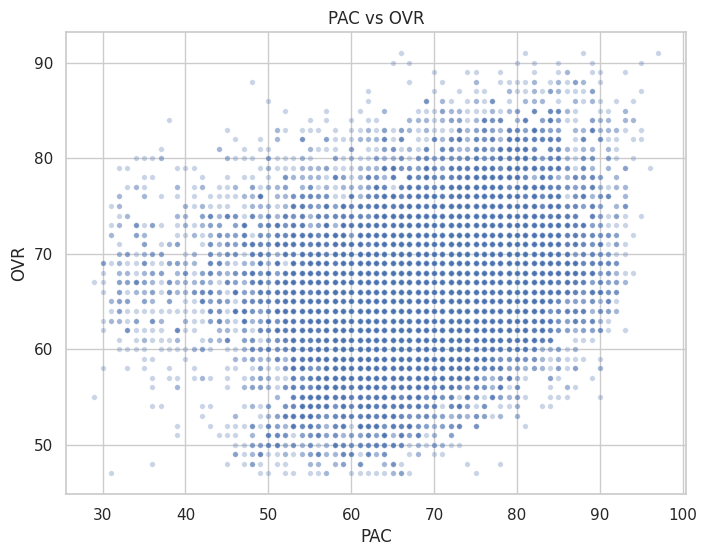

,PAC,OVR
PAC,1.000000,0.286057
OVR,0.286057,1.000000


In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PAC", y="OVR", alpha=0.3, s=15)
plt.title("PAC vs OVR")
plt.show()

df[["PAC","OVR"]].corr()

**Interprétation :** le nuage de points ne montre pas de relation linéaire forte entre le **PAC** et l'**OVR** — le coefficient de corrélation est faible. C'est cohérent avec le fait que l'OVR est une synthèse de nombreuses qualités (technique, physique, mental...) et pas seulement de la vitesse : un joueur peut être très bien noté sans être rapide (ex. certains milieux de terrain ou défenseurs).

#### 3.7 Régression linéaire entre DRI et OVR

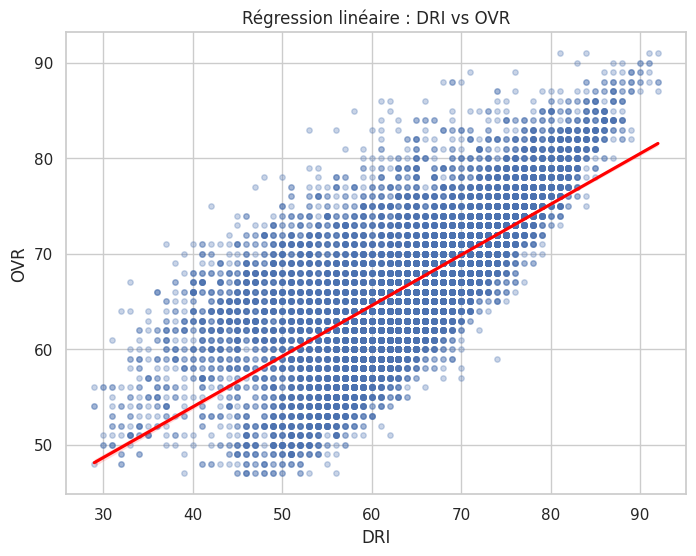

,DRI,OVR
DRI,1.000000,0.706519
OVR,0.706519,1.000000


In [14]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="DRI", y="OVR", scatter_kws={"alpha":0.3, "s":15}, line_kws={"color":"red"})
plt.title("Régression linéaire : DRI vs OVR")
plt.show()

df[["DRI","OVR"]].corr()

**Interprétation :** contrairement au PAC, le **DRI** est beaucoup plus corrélé positivement à l'**OVR** : la droite de régression a une pente nette et positive. Le dribble/la technique semble être une des composantes les plus déterminantes de la note globale, ce qui est logique pour un jeu qui valorise fortement le toucher de balle.

#### 3.8 Jointplot PAS vs DRI

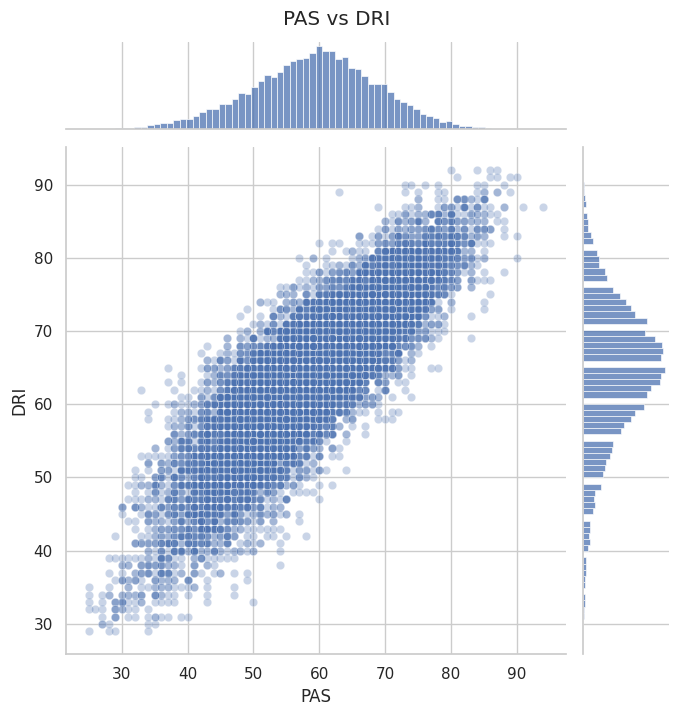

In [15]:
sns.jointplot(data=df, x="PAS", y="DRI", kind="scatter", height=7, alpha=0.3)
plt.suptitle("PAS vs DRI", y=1.02)
plt.show()

**Interprétation :** le jointplot met en évidence une relation positive assez marquée entre le **PAS** (passe) et le **DRI** (dribble) : les joueurs techniques ont souvent aussi une bonne vision/qualité de passe. Les histogrammes marginaux confirment que les deux variables ont des distributions asymétriques similaires, avec une masse importante entre 55 et 75.

#### 3.9 Pairplot OVR, PAC, SHO, PAS, DRI

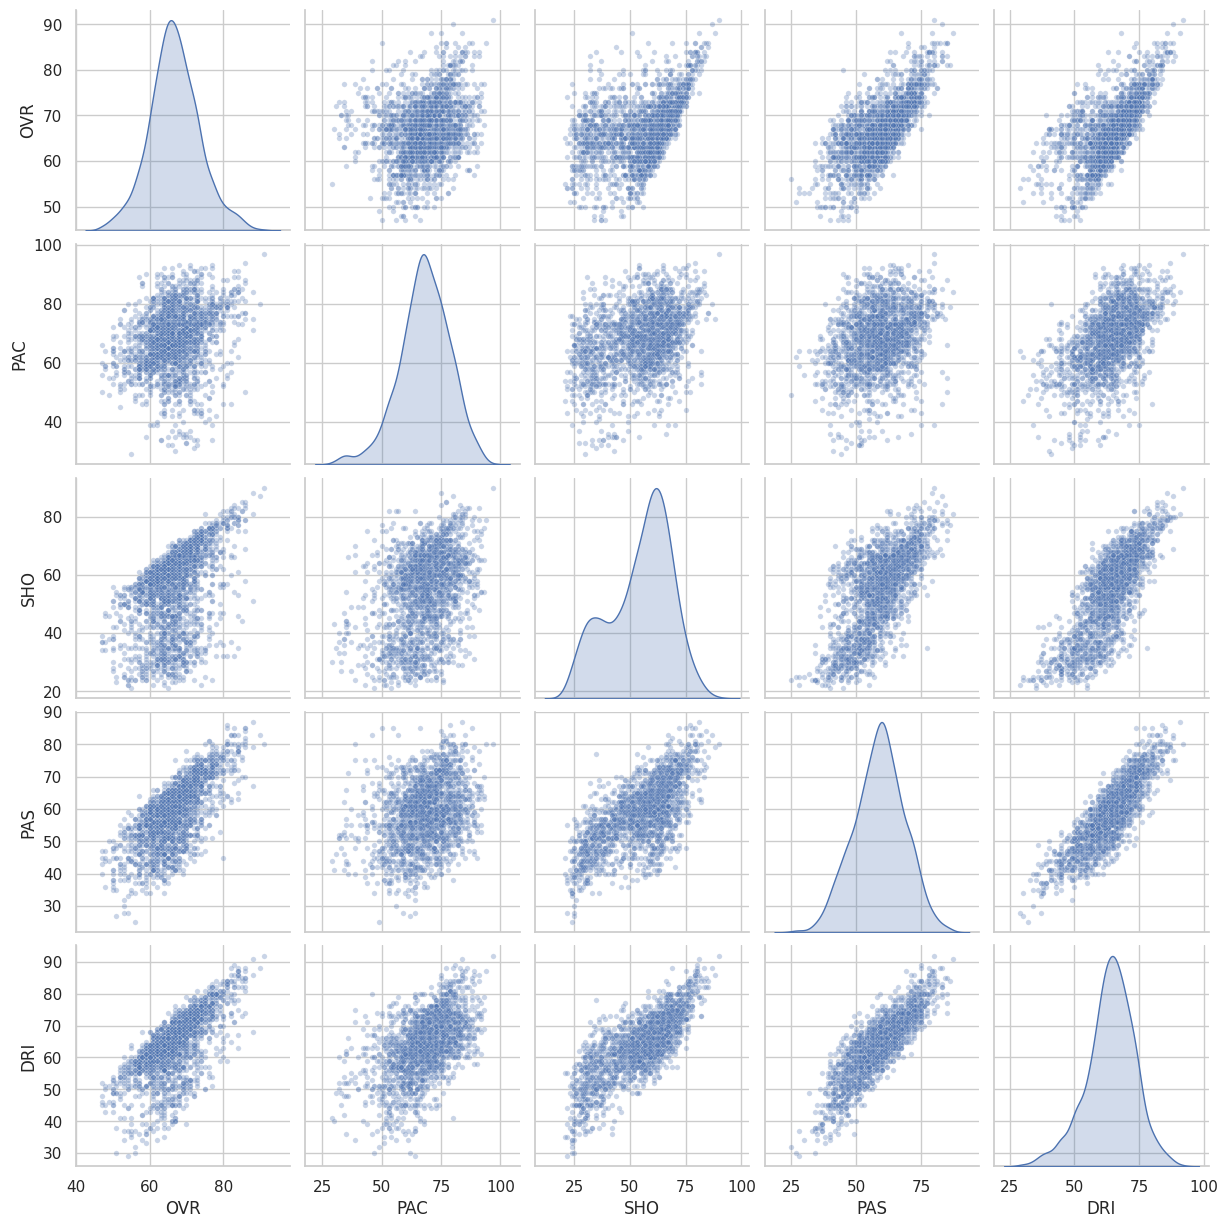

In [16]:
cols = ["OVR","PAC","SHO","PAS","DRI"]
sns.pairplot(df[cols].sample(2000, random_state=42), diag_kind="kde", plot_kws={"alpha":0.3, "s":15})
plt.show()

**Interprétation :** (échantillon de 2000 joueurs pour la lisibilité) le pairplot confirme que **SHO**, **PAS** et **DRI** sont assez corrélées entre elles et avec l'**OVR** — ce sont les qualités « offensives/techniques » qui vont souvent de pair. Le **PAC** reste la variable la plus indépendante du groupe, ce qui traduit bien le fait que la vitesse est une qualité physique à part, pas forcément liée au niveau technique global.

### Boxplot / violinplot / barplot

#### 3.10 OVR par League (boxplot)

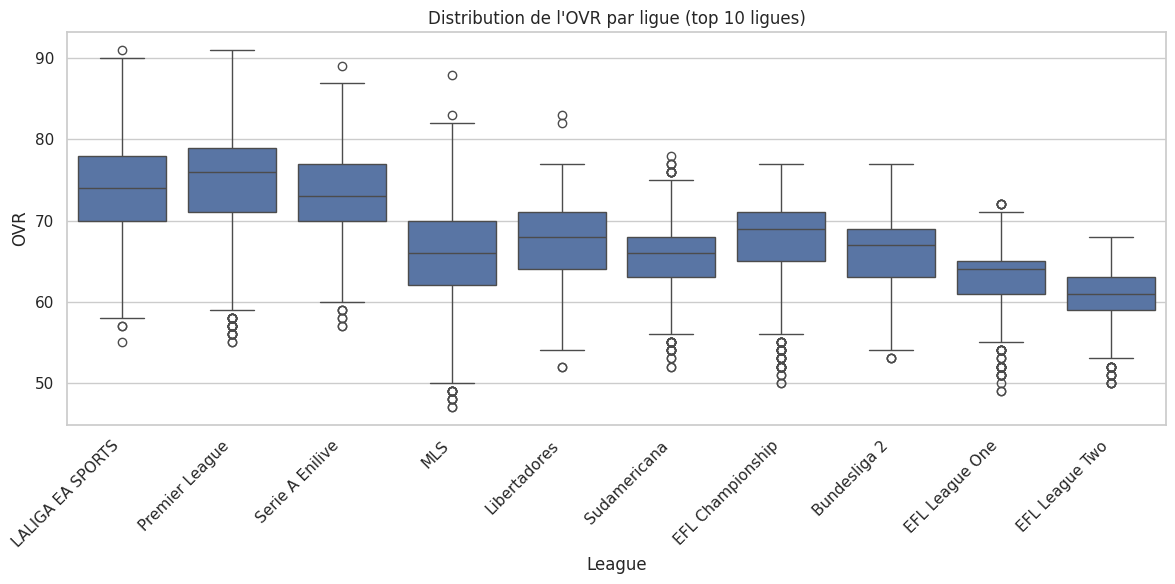

In [17]:
top10_leagues = df["League"].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df["League"].isin(top10_leagues)], x="League", y="OVR")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution de l'OVR par ligue (top 10 ligues)")
plt.tight_layout()
plt.show()

**Interprétation :** (limité aux 10 ligues les plus représentées pour la lisibilité) on observe des médianes d'OVR assez proches entre ligues, mais la **Premier League** et la **LaLiga** ont des boîtes légèrement plus hautes et davantage de valeurs extrêmes hautes (superstars), alors que les divisions inférieures anglaises (League One, League Two) ont des médianes plus basses et moins d'outliers vers le haut.

#### 3.11 PAC, DRI, SHO entre 3 grands championnats

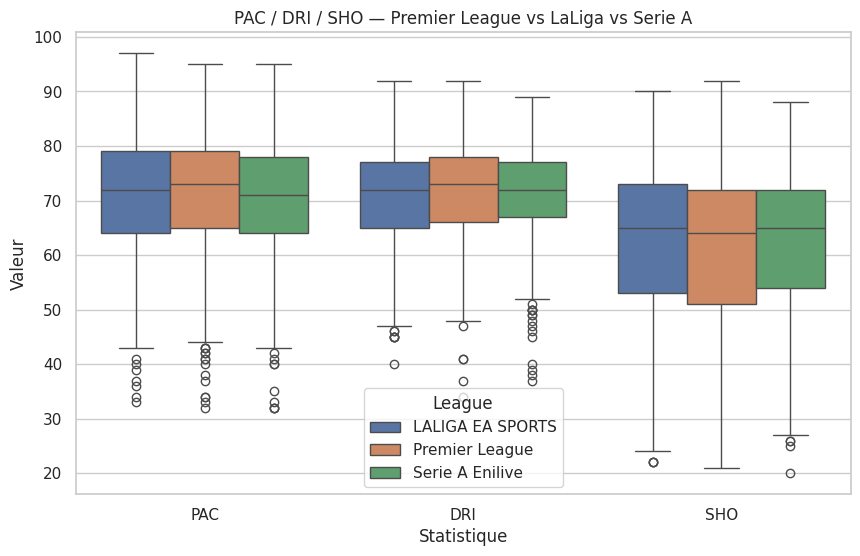

In [18]:
big3 = ["Premier League", "LALIGA EA SPORTS", "Serie A Enilive"]
sub = df[df["League"].isin(big3)][["League","PAC","DRI","SHO"]]
sub_melt = sub.melt(id_vars="League", var_name="Statistique", value_name="Valeur")

plt.figure(figsize=(10,6))
sns.boxplot(data=sub_melt, x="Statistique", y="Valeur", hue="League")
plt.title("PAC / DRI / SHO — Premier League vs LaLiga vs Serie A")
plt.show()

**Interprétation :** les trois championnats affichent des profils très proches sur ces trois statistiques, signe que le niveau technique et athlétique moyen des grandes ligues européennes est homogène. On note toutefois une légère avance de la **Premier League** sur le PAC (vitesse), ce qui correspond à sa réputation de championnat plus intense physiquement.

#### 3.12 Violinplot DRI par poste

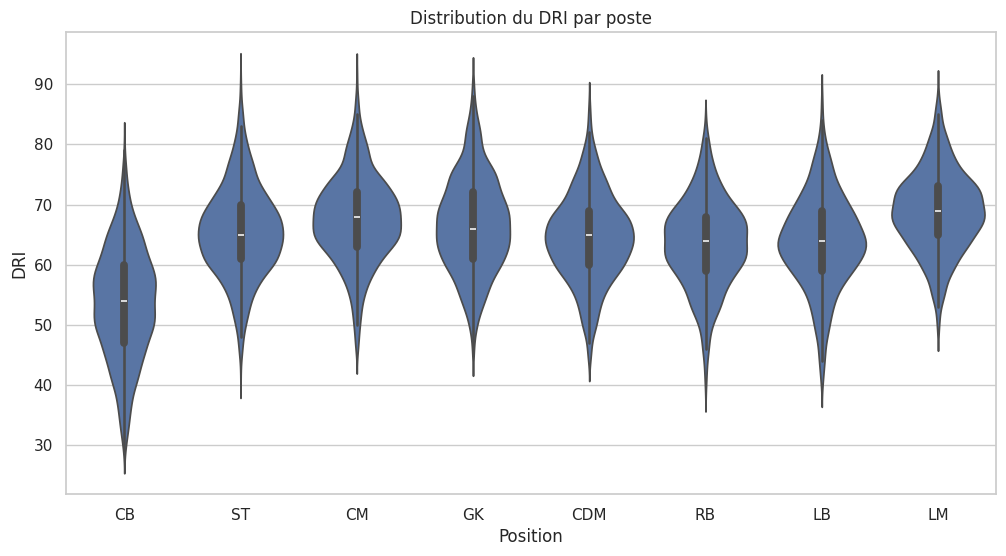

In [19]:
top_positions = df["Position"].value_counts().head(8).index
plt.figure(figsize=(12,6))
sns.violinplot(data=df[df["Position"].isin(top_positions)], x="Position", y="DRI", order=top_positions)
plt.title("Distribution du DRI par poste")
plt.show()

**Interprétation :** sans surprise, les postes offensifs (**ST**, **CAM**, **LM/RM**) ont des violons de DRI centrés sur des valeurs élevées et resserrées, tandis que les postes défensifs (**CB**, **GK**) ont des distributions beaucoup plus basses et étalées vers le bas. Le poste influence donc très fortement cette statistique.

#### 3.13 Championnat avec la plus grande moyenne PHY

In [20]:
phy_by_league = df.groupby("League")["PHY"].mean().sort_values(ascending=False).head(10)
phy_by_league

League
Calcio A Femminile    71.000000
Česká Liga            70.987013
Premier League        69.916248
Hellas Liga           69.734513
Bundesliga            69.622680
Serie A Enilive       69.383613
Liga Hrvatska         68.166667
LALIGA EA SPORTS      68.128544
Barclays WSL          68.054902
Ligue 1 McDonald's    67.987069
Name: PHY, dtype: float64

/tmp/ipykernel_136/2017649092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phy_by_league.values, y=phy_by_league.index, palette="rocket")


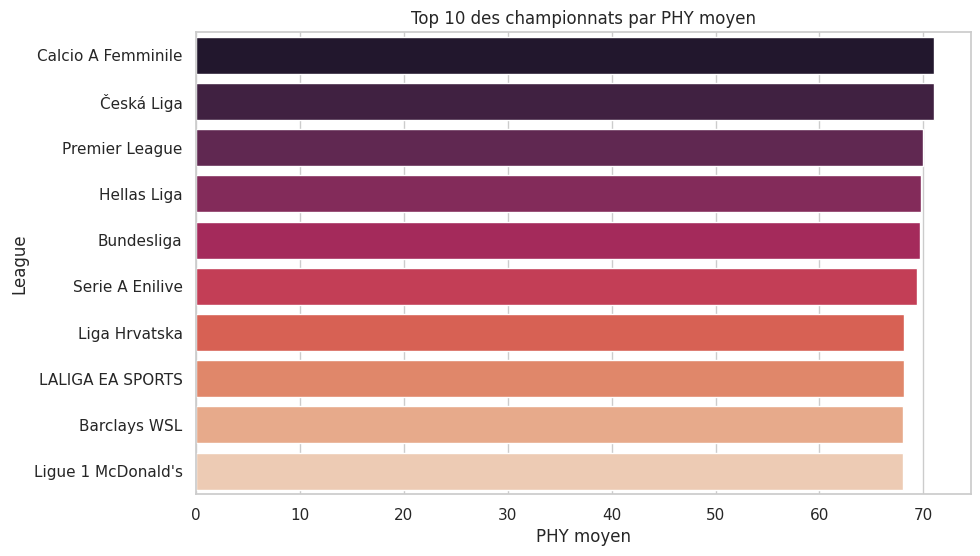

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x=phy_by_league.values, y=phy_by_league.index, palette="rocket")
plt.xlabel("PHY moyen")
plt.title("Top 10 des championnats par PHY moyen")
plt.show()

**Interprétation :** le championnat avec la plus grande moyenne de **PHY** apparaît en tête du classement ci-dessus. Ce sont souvent des ligues moins médiatisées mais réputées pour leur intensité physique plutôt que technique, ce qui illustre que le physique moyen n'est pas nécessairement corrélé au prestige ou au niveau technique d'un championnat.

## 4. Visualisations multivariées

#### 4.14 Catplot OVR par League, séparé par Nation (top 5 nations)

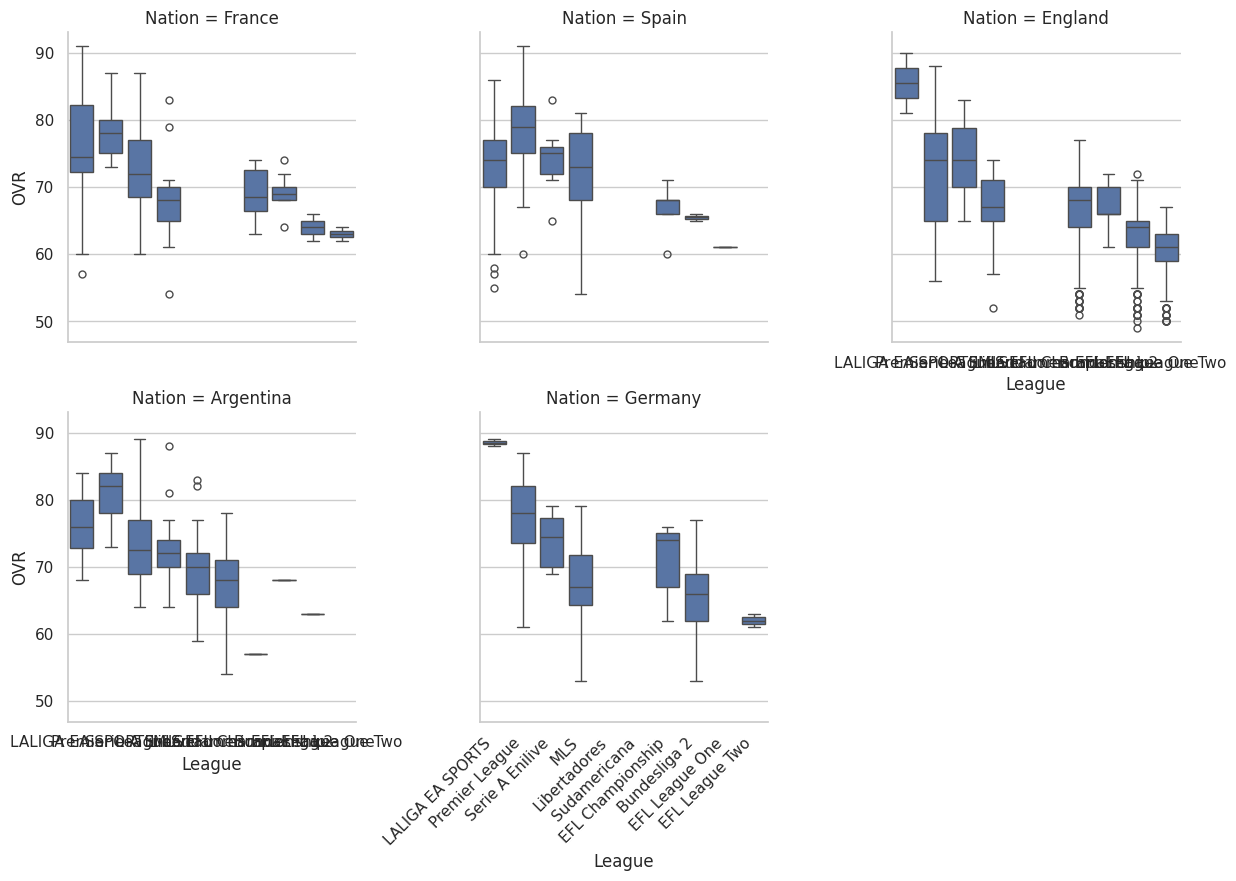

In [22]:
top5_nations = df["Nation"].value_counts().head(5).index
sub = df[df["Nation"].isin(top5_nations) & df["League"].isin(top10_leagues)]

sns.catplot(data=sub, x="League", y="OVR", col="Nation", kind="box", col_wrap=3, height=4, aspect=1)
plt.xticks(rotation=45, ha="right")
plt.show()

**Interprétation :** en séparant par nation, on voit que les joueurs anglais et espagnols ont tendance à avoir un OVR médian un peu plus élevé dans leur championnat national respectif que les joueurs d'autres nationalités jouant dans les mêmes ligues — un effet probable de sélection (les meilleurs joueurs locaux restent dans leur championnat national).

#### 4.15 lmplot PAC vs SHO, coloré par league

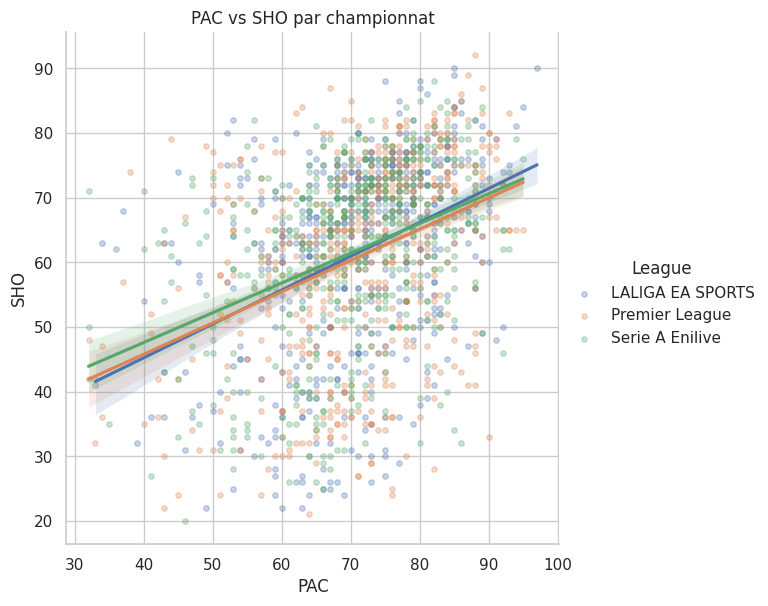

In [23]:
sub = df[df["League"].isin(big3)]
sns.lmplot(data=sub, x="PAC", y="SHO", hue="League", height=6, scatter_kws={"alpha":0.3, "s":15})
plt.title("PAC vs SHO par championnat")
plt.show()

**Interprétation :** les trois droites de régression sont quasiment parallèles et toutes positives : dans chaque championnat, plus un joueur est rapide, plus il a tendance à avoir un bon score de tir. Les pentes très similaires confirment que la relation entre vitesse et finition est une caractéristique assez universelle du jeu, indépendante du championnat.

#### 4.16 Heatmap de corrélation

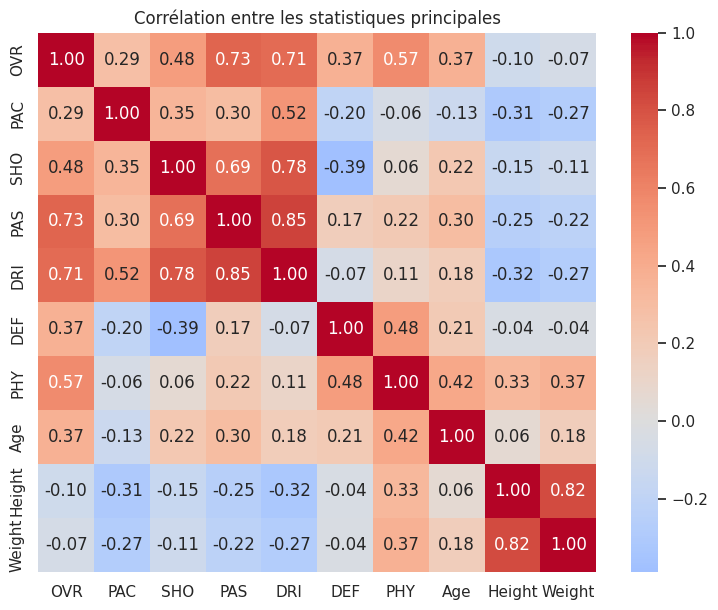

In [24]:
main_stats = ["OVR","PAC","SHO","PAS","DRI","DEF","PHY","Age","Height","Weight"]
corr = df[main_stats].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélation entre les statistiques principales")
plt.show()

**Interprétation :** la heatmap confirme les observations précédentes : **DRI**, **SHO** et **PAS** sont fortement corrélées entre elles et avec l'**OVR**, tandis que **PAC** est nettement moins corrélé. **DEF** est même souvent négativement corrélé avec les statistiques offensives, ce qui reflète la spécialisation des postes (un joueur très défensif est rarement aussi un grand dribbleur).

#### 4.17 FacetGrid : distribution de OVR séparée par ligue

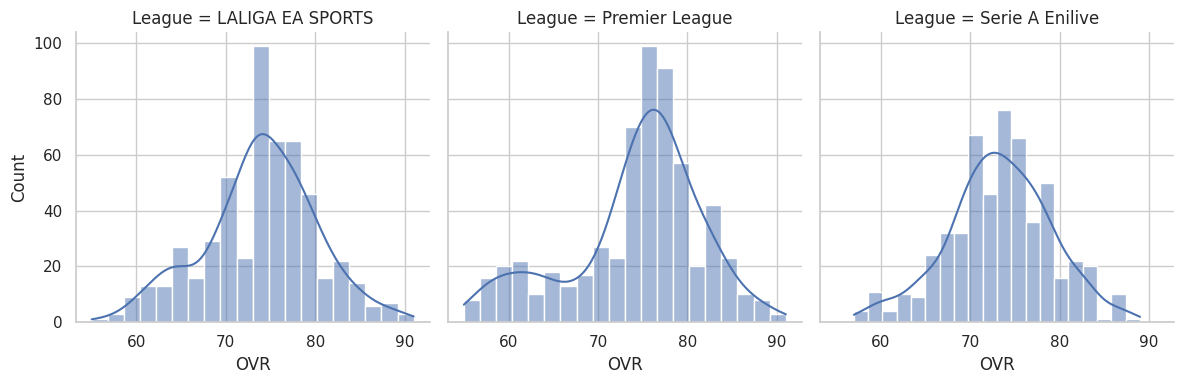

In [25]:
g = sns.FacetGrid(df[df["League"].isin(big3)], col="League", height=4)
g.map(sns.histplot, "OVR", bins=20, kde=True)
plt.show()

**Interprétation :** les trois distributions ont des formes très similaires (cloche centrée autour de 67-70), ce qui confirme que le niveau moyen des trois grands championnats européens est comparable dans ce dataset, avec juste de légères variations de dispersion.

## 5. Visualisations orientées performance sportive

#### 5.18 Ligue avec les joueurs les plus explosifs (Acceleration + Sprint Speed)

/tmp/ipykernel_136/3084275027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=explosive_by_league.values, y=explosive_by_league.index, palette="flare")


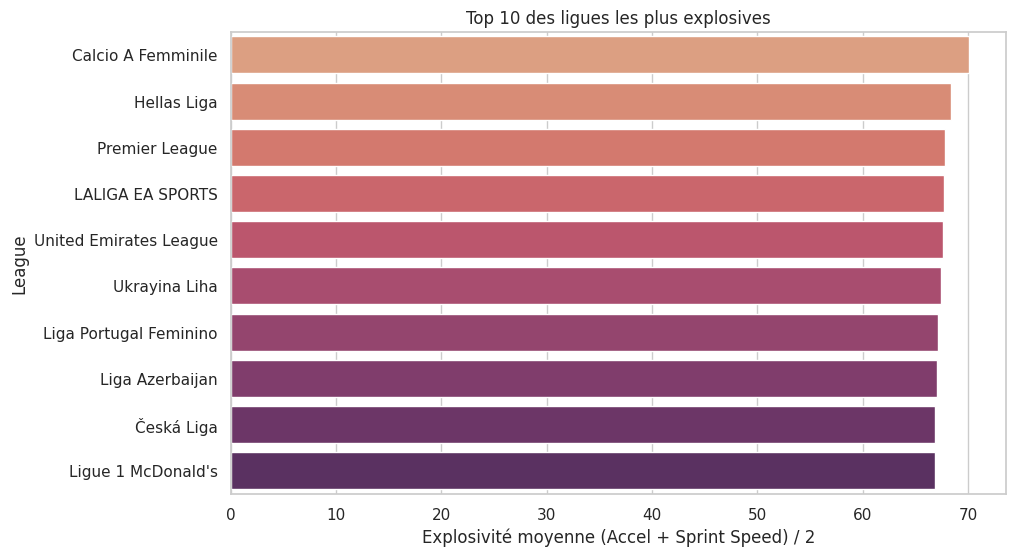

In [26]:
df["Explosivite"] = (df["Acceleration"] + df["Sprint.Speed"]) / 2
explosive_by_league = df.groupby("League")["Explosivite"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=explosive_by_league.values, y=explosive_by_league.index, palette="flare")
plt.xlabel("Explosivité moyenne (Accel + Sprint Speed) / 2")
plt.title("Top 10 des ligues les plus explosives")
plt.show()

**Interprétation :** la ligue en tête de ce classement regroupe les joueurs les plus rapides à l'accélération et en pointe de vitesse. On retrouve ici encore des championnats parfois moins prestigieux mais où le jeu privilégie la vitesse pure, ce qui montre que l'explosivité physique n'est pas l'apanage des seuls grands championnats.

#### 5.19 Équilibre Attaque vs Défense : (SHO + DRI) vs DEF

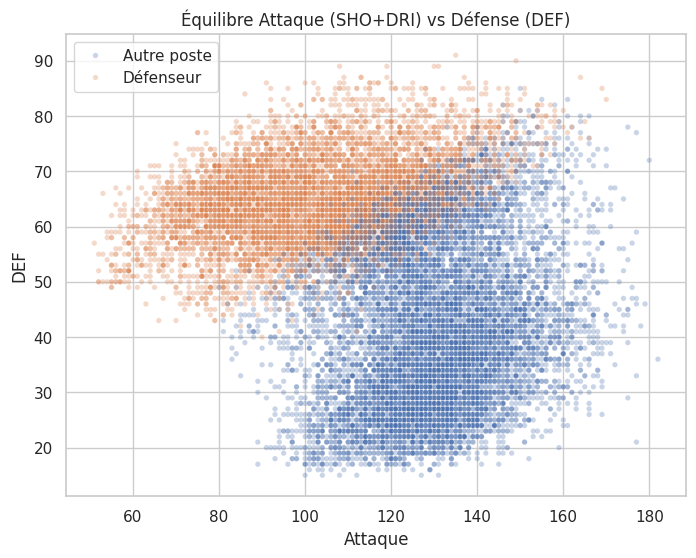

In [27]:
df["Attaque"] = df["SHO"] + df["DRI"]
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Attaque", y="DEF", alpha=0.3, s=15, hue=df["Position"].isin(["CB","CDM","LB","RB"]).map({True:"Défenseur", False:"Autre poste"}))
plt.title("Équilibre Attaque (SHO+DRI) vs Défense (DEF)")
plt.legend(title="")
plt.show()

**Interprétation :** le nuage de points dessine deux nuages assez distincts : les défenseurs (points colorés différemment) se concentrent en haut à gauche (fort DEF, faible score d'attaque), et les autres postes en bas à droite (fort score d'attaque, faible DEF). Peu de joueurs cumulent les deux qualités à un haut niveau — la spécialisation des postes est très marquée dans ce jeu.

#### 5.20 Profil moyen d'un joueur par championnat (radar chart, bonus)

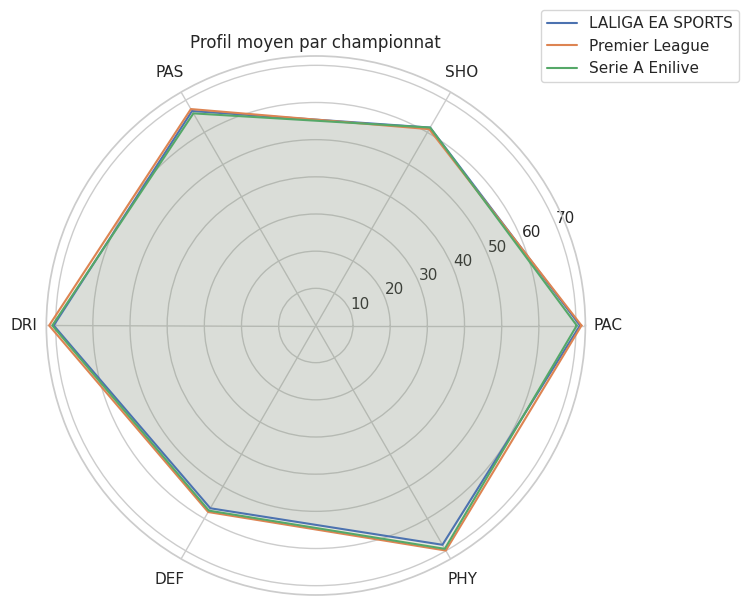

In [28]:
from math import pi

radar_stats = ["PAC","SHO","PAS","DRI","DEF","PHY"]
leagues_radar = big3
profiles = df[df["League"].isin(leagues_radar)].groupby("League")[radar_stats].mean()

angles = [n / float(len(radar_stats)) * 2 * pi for n in range(len(radar_stats))]
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)
for league in profiles.index:
    values = profiles.loc[league].tolist()
    values += values[:1]
    ax.plot(angles, values, label=league)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_stats)
plt.title("Profil moyen par championnat")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

**Interprétation :** les trois radars se superposent presque parfaitement sur PAC, SHO, PAS et DRI, confirmant l'homogénéité déjà observée. La plus petite différence visible se situe sur DEF et PHY, où un des championnats ressort légèrement au-dessus des autres, cohérent avec sa réputation de championnat plus physique/défensif.

## 6. Exercices avancés

#### 6.21 Les 10 clubs avec les meilleures moyennes de OVR

/tmp/ipykernel_136/1116564751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_clubs.values, y=top10_clubs.index, palette="mako")


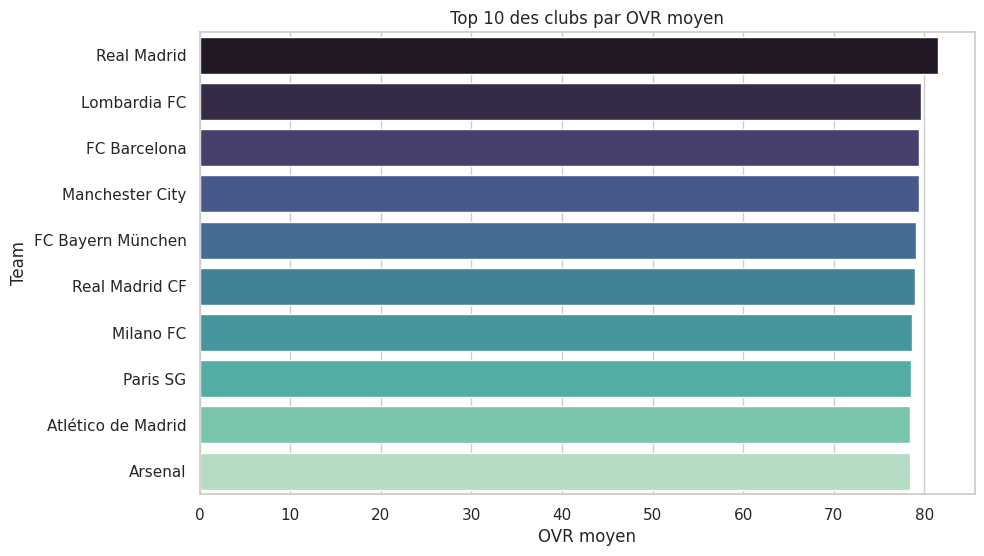

In [29]:
top10_clubs = df.groupby("Team")["OVR"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_clubs.values, y=top10_clubs.index, palette="mako")
plt.xlabel("OVR moyen")
plt.title("Top 10 des clubs par OVR moyen")
plt.show()

**Interprétation :** les clubs en tête de ce classement sont les grandes écuries européennes bien connues (typiquement les cadors de LaLiga/Premier League/Serie A). Leur moyenne d'OVR très élevée confirme qu'ils concentrent l'essentiel des meilleurs joueurs mondiaux, contrairement aux clubs de divisions inférieures qui tirent la moyenne générale du dataset vers le bas.

#### 6.22 Gardiens de but vs joueurs de champ

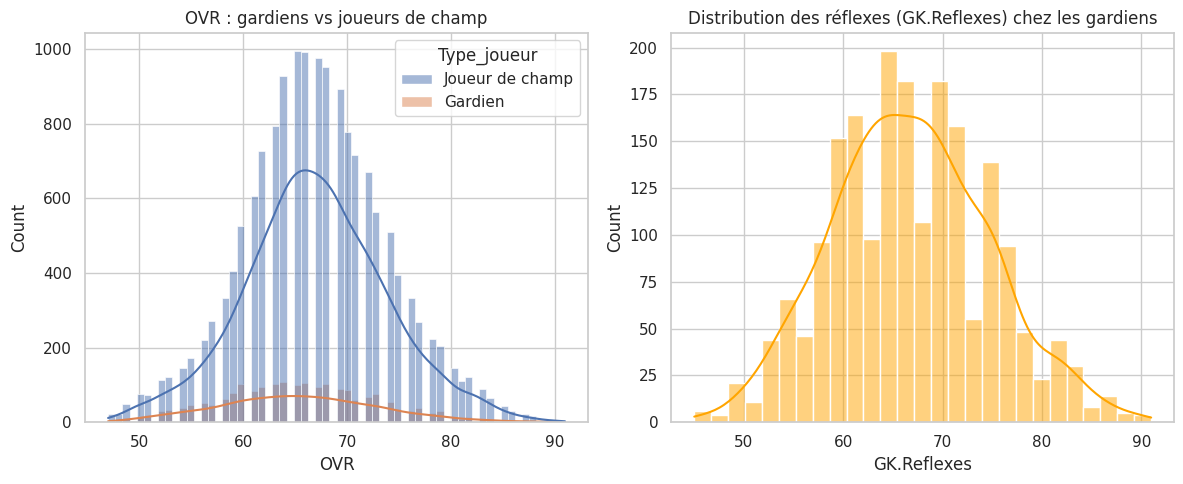

In [30]:
df["Type_joueur"] = np.where(df["Position"] == "GK", "Gardien", "Joueur de champ")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(data=df, x="OVR", hue="Type_joueur", kde=True, ax=axes[0])
axes[0].set_title("OVR : gardiens vs joueurs de champ")

sns.histplot(data=df[df["Type_joueur"]=="Gardien"], x="GK.Reflexes", kde=True, color="orange", ax=axes[1])
axes[1].set_title("Distribution des réflexes (GK.Reflexes) chez les gardiens")
plt.tight_layout()
plt.show()

**Interprétation :** les **1 999 gardiens** du dataset ont une distribution d'OVR globalement proche de celle des joueurs de champ, mais évaluée sur des critères totalement différents (les colonnes GK.Diving, GK.Handling, etc. ne concernent qu'eux, alors que PAC/DRI/SHO n'ont pas vraiment de sens pour un poste de gardien). Le graphique des réflexes montre une distribution resserrée, ce qui est cohérent avec le fait que les réflexes sont une compétence discriminante et bien notée pour ce poste spécialisé.

#### 6.23 Comparaison de la variance des statistiques entre championnats (boxplot global)

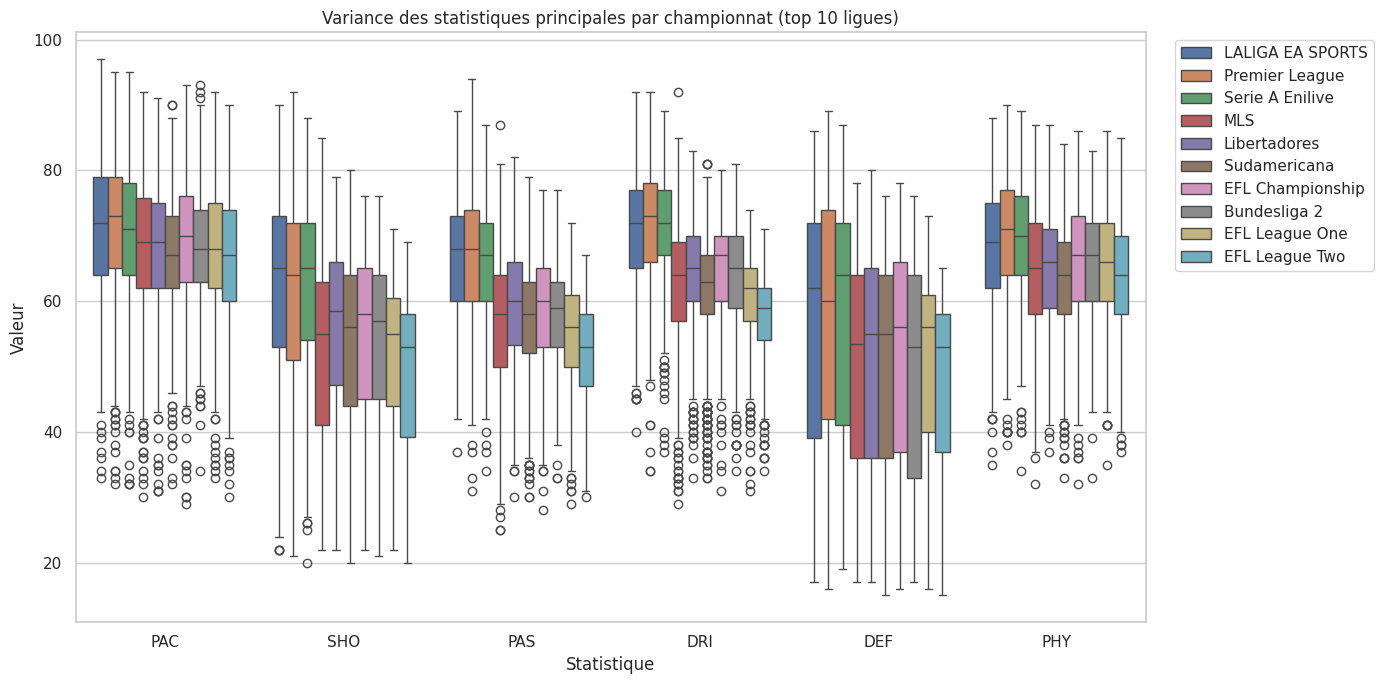

In [31]:
main_stats2 = ["PAC","SHO","PAS","DRI","DEF","PHY"]
sub = df[df["League"].isin(top10_leagues)][["League"] + main_stats2].melt(id_vars="League", var_name="Statistique", value_name="Valeur")

plt.figure(figsize=(14,7))
sns.boxplot(data=sub, x="Statistique", y="Valeur", hue="League")
plt.title("Variance des statistiques principales par championnat (top 10 ligues)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

**Interprétation :** toutes les ligues ont des variances globalement comparables pour chaque statistique (les boîtes ont des tailles similaires), mais on note que les divisions inférieures (League One, League Two) affichent des boîtes légèrement plus larges sur DRI et PAS : le niveau y est plus hétérogène, avec à la fois de bons techniciens et des joueurs plus limités, contrairement aux grandes ligues où le niveau est plus homogène vers le haut.

#### 6.24 Variation des stats physiques (PHY, DEF) par nation

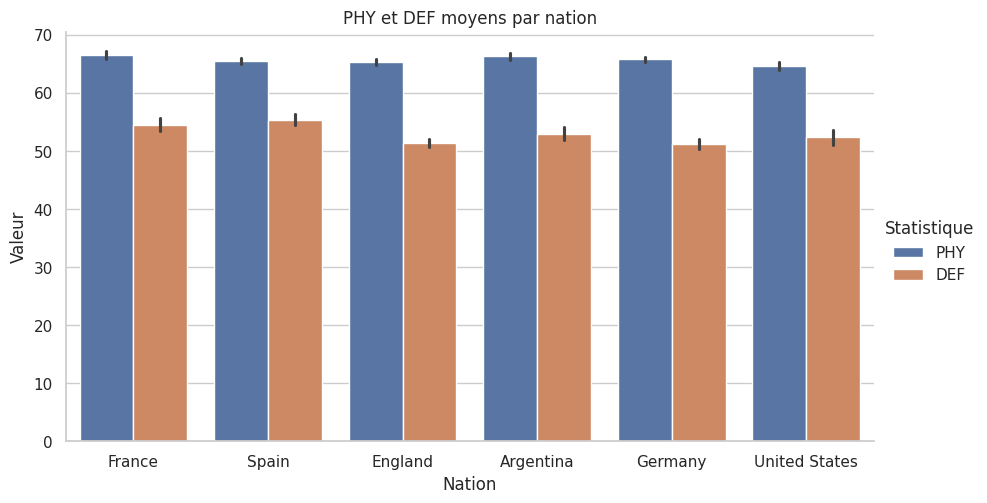

In [32]:
top_nations2 = df["Nation"].value_counts().head(6).index
sub = df[df["Nation"].isin(top_nations2)][["Nation","PHY","DEF"]].melt(id_vars="Nation", var_name="Statistique", value_name="Valeur")

sns.catplot(data=sub, x="Nation", y="Valeur", hue="Statistique", kind="bar", height=5, aspect=1.8)
plt.title("PHY et DEF moyens par nation")
plt.show()

**Interprétation :** les moyennes de **PHY** et **DEF** varient assez peu d'une nation à l'autre parmi les 6 les plus représentées, ce qui suggère que ces statistiques sont davantage liées au poste occupé par le joueur qu'à sa nationalité. On note tout de même de petits écarts qui peuvent refléter des styles de jeu nationaux différents (championnats plus physiques ou plus techniques selon les pays).

## Conclusion

Ce TP a permis de parcourir l'ensemble des familles de graphiques Seaborn (univariés, bivariés, multivariés) sur un dataset réel de plus de 17 000 joueurs. Les grands enseignements :

- L'**OVR** est surtout tiré par les qualités techniques/offensives (**DRI**, **SHO**, **PAS**) plus que par le **PAC**.
- Les postes déterminent très fortement le profil statistique d'un joueur (opposition nette attaque/défense).
- Les grands championnats européens (Premier League, LaLiga, Serie A) ont des profils moyens très proches.
- Les clubs et ligues d'élite concentrent les meilleures moyennes d'OVR, alors que les divisions inférieures et certaines ligues moins médiatisées tirent la moyenne générale vers le bas tout en affichant parfois des profils physiques ou une variance différents.